# Análisis de Componentes Principales (PCA) - Formula 1

Este notebook continúa el trabajo iniciado en el EDA. La idea es tomar la base ya depurada (`df_model`) y construir un PCA con las variables numéricas relevantes para resumir la información en un conjunto menor de componentes principales.

Además de interpretar las componentes, se guarda una matriz de scores del PCA para usarla después como entrada del análisis cluster.

## 1. Objetivo del PCA

El PCA se usa para transformar un conjunto de variables numéricas posiblemente correlacionadas en nuevas variables llamadas **componentes principales**.

Cada componente principal cumple dos condiciones importantes:

1. Es una combinación lineal de las variables originales.
2. Está construida para explicar la mayor cantidad posible de variabilidad, manteniendo independencia lineal respecto de las componentes anteriores.

En este trabajo, el PCA se usa con dos fines:

- **Interpretativo:** entender cuáles son los principales ejes de variabilidad del rendimiento en Fórmula 1.
- **Operativo:** generar una matriz reducida de componentes principales para usar luego en clustering.

In [19]:
# ============================================================
# 1) IMPORTS Y CONFIGURACIÓN GENERAL
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from matplotlib.patches import Circle
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

sns.set_theme(style="whitegrid")

MOSTRAR_GRAFICOS = True

# ------------------------------------------------------------
# Detectar carpeta raíz del proyecto
# ------------------------------------------------------------

def encontrar_raiz_proyecto():
    """
    Busca hacia arriba una carpeta que contenga data/processed.
    Esto permite ejecutar el notebook desde notebooks/pca o desde la raíz del proyecto.
    """
    actual = Path.cwd()
    
    for carpeta in [actual] + list(actual.parents):
        if (carpeta / "data" / "processed").exists():
            return carpeta
    
    raise FileNotFoundError(
        "No se encontró la carpeta data/processed. "
        "Revisá que estés dentro del proyecto Analisis-multivariado."
    )

BASE_DIR = encontrar_raiz_proyecto()
DATA_PROCESSED = BASE_DIR / "data" / "processed"
REPORTS_DIR = BASE_DIR / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
MODEL_RESULTS_DIR = REPORTS_DIR / "model_results"

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODEL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Carpeta raíz del proyecto:", BASE_DIR)
print("Carpeta de datos procesados:", DATA_PROCESSED)
print("Carpeta de figuras:", FIGURES_DIR)
print("Carpeta de resultados del modelo:", MODEL_RESULTS_DIR)

Carpeta raíz del proyecto: /Users/juani/Desktop/Facultad/3er año/Analisis Multivariado y Descrubrimiento de Patrones/Analisis-multivariado
Carpeta de datos procesados: /Users/juani/Desktop/Facultad/3er año/Analisis Multivariado y Descrubrimiento de Patrones/Analisis-multivariado/data/processed
Carpeta de figuras: /Users/juani/Desktop/Facultad/3er año/Analisis Multivariado y Descrubrimiento de Patrones/Analisis-multivariado/reports/figures
Carpeta de resultados del modelo: /Users/juani/Desktop/Facultad/3er año/Analisis Multivariado y Descrubrimiento de Patrones/Analisis-multivariado/reports/model_results


## 2. Carga de la base de trabajo

El notebook está preparado para usar `df_model` si ya existe en memoria. Si se ejecuta de forma independiente, carga la base final guardada por el EDA:

`data/processed/formula1_base_trabajo.csv`

Esto permite mantener conectadas las etapas del trabajo sin tener que repetir todo el preprocesamiento.

In [20]:
# ============================================================
# 2) CARGA DE LA BASE FINAL DE TRABAJO
# ============================================================

archivo_base = DATA_PROCESSED / "formula1_base_trabajo.csv"

try:
    df_pca_base = df_model.copy()
    print("Se usa df_model desde memoria.")
except NameError:
    df_pca_base = pd.read_csv(archivo_base)
    print("Se cargó la base desde:", archivo_base)

print("Dimensiones de la base:")
print(df_pca_base.shape)

display(df_pca_base.head())

Se cargó la base desde: /Users/juani/Desktop/Facultad/3er año/Analisis Multivariado y Descrubrimiento de Patrones/Analisis-multivariado/data/processed/formula1_base_trabajo.csv
Dimensiones de la base:
(10000, 43)


,year,decada,round,race_name,race_date,circuit_name,circuit_country,circuit_location,driver_name,driver_nationality,driver_age,constructor_name,constructor_nationality,grid,largada_grupo,positionOrder,resultado_grupo,race_points,laps,status,status_grupo,driver_championship_points,driver_championship_position,driver_championship_wins,resultId,raceId,driverId,constructorId,statusId,circuitId,driverRef,dob,constructorRef,circuitRef,circuit_lat,circuit_lng,circuit_alt,podio,top10,victoria,laps_max_race,laps_pct,vueltas_perdidas
0,2024,2020s,12,British Grand Prix,2024-07-07,Silverstone Circuit,UK,Silverstone,Oscar Piastri,Australian,23.252567,McLaren,British,5,Top 5,4,Top 10,12.0,52,Finished,Clasificado / terminó,124.0,5.0,0.0,26508,1132,857,1,1,9,piastri,2001-04-06,mclaren,silverstone,52.07860,-1.01694,153,0,1,0,52,1.000000,0
1,2008,2000s,2,Malaysian Grand Prix,2008-03-23,Sepang International Circuit,Malaysia,Kuala Lumpur,Giancarlo Fisichella,Italian,35.186858,Force India,Indian,17,Fondo,12,Fuera del top 10,0.0,55,+1 Lap,Clasificado / terminó,0.0,15.0,0.0,34,19,21,10,11,2,fisichella,1973-01-14,force_india,sepang,2.76083,101.73800,18,0,0,0,56,0.982143,1
2,2005,2000s,12,German Grand Prix,2005-07-24,Hockenheimring,Germany,Hockenheim,Narain Karthikeyan,Indian,28.522930,Jordan,Irish,19,Fondo,16,Fuera del top 10,0.0,64,+3 Laps,Clasificado / terminó,5.0,17.0,0.0,1370,82,39,17,13,10,karthikeyan,1977-01-14,jordan,hockenheimring,49.32780,8.56583,103,0,0,0,67,0.955224,3
3,2009,2000s,16,Brazilian Grand Prix,2009-10-18,Autódromo José Carlos Pace,Brazil,São Paulo,Adrian Sutil,German,26.767967,Force India,Indian,3,Top 5,18,Fuera del top 10,0.0,0,Accident,Incidente / abandono,5.0,16.0,0.0,7871,16,16,10,3,18,sutil,1983-01-11,force_india,interlagos,-23.70360,-46.69970,785,0,0,0,71,0.000000,71
4,2000,2000s,16,Japanese Grand Prix,2000-10-08,Suzuka Circuit,Japan,Suzuka,Giancarlo Fisichella,Italian,27.731691,Benetton,Italian,12,Fondo,14,Fuera del top 10,0.0,52,+1 Lap,Clasificado / terminó,18.0,6.0,0.0,3273,173,21,22,11,22,fisichella,1973-01-14,benetton,suzuka,34.84310,136.54100,45,0,0,0,53,0.981132,1


## 3. Selección de variables activas y suplementarias

Para el PCA se usan solamente variables numéricas interpretables. No se incluyen identificadores técnicos como `raceId`, `driverId`, `constructorId` o `resultId`, porque son códigos y no magnitudes analizables.

Tampoco se incluyen como variables activas `podio`, `top10` o `victoria`, porque son variables binarias derivadas directamente de la posición final. Incluirlas junto con `positionOrder` duplicaría información.

La variable `posiciones_ganadas` se calcula como:

`grid - positionOrder`

pero se deja como variable suplementaria para interpretar resultados, no como variable activa del PCA, porque es una combinación directa de dos variables ya incluidas (`grid` y `positionOrder`).

In [21]:
# ============================================================
# 3) SELECCIÓN DE VARIABLES PARA PCA
# ============================================================

# Copia de trabajo
df_pca = df_pca_base.copy()

# Variable derivada útil para interpretar, pero no activa en el PCA.
# Valor positivo: el piloto terminó mejor de lo que largó.
# Valor negativo: el piloto perdió posiciones.
if {"grid", "positionOrder"}.issubset(df_pca.columns):
    df_pca["posiciones_ganadas"] = df_pca["grid"] - df_pca["positionOrder"]

# Variables activas: entran efectivamente al PCA.
variables_pca_activas = [
    "grid",
    "positionOrder",
    "laps_pct",
    "driver_age",
    "driver_championship_position",
    "driver_championship_wins"
]

variables_pca_activas = [
    col for col in variables_pca_activas
    if col in df_pca.columns
]

# Variables suplementarias: no entran al PCA, pero se conservan para interpretar scores y clusters.
variables_suplementarias = [
    "resultId",
    "raceId",
    "driverId",
    "constructorId",
    "circuitId",
    "year",
    "decada",
    "race_name",
    "race_date",
    "circuit_name",
    "circuit_country",
    "driver_name",
    "driver_nationality",
    "constructor_name",
    "constructor_nationality",
    "largada_grupo",
    "resultado_grupo",
    "status",
    "status_grupo",
    "podio",
    "top10",
    "victoria",
    "posiciones_ganadas"
]

variables_suplementarias = [
    col for col in variables_suplementarias
    if col in df_pca.columns
]

# Variables que se excluyen del PCA
# Se excluyen los puntos porque el sistema de puntuación de Fórmula 1 cambió a lo largo del tiempo.
# Por lo tanto, los puntos brutos no son completamente comparables entre décadas.

variables_excluir_pca = [
    "race_points",
    "driver_championship_points"
]

print("Variables activas del PCA:")
print(variables_pca_activas)

print("\nVariables suplementarias conservadas:")
print(variables_suplementarias)

print("\nVariables excluidas del PCA:")
print(variables_excluir_pca)

pd.DataFrame({"variable": variables_pca_activas}).to_csv(
    DATA_PROCESSED / "formula1_pca_variables_activas.csv",
    index=False
)

Variables activas del PCA:
['grid', 'positionOrder', 'laps_pct', 'driver_age', 'driver_championship_position', 'driver_championship_wins']

Variables suplementarias conservadas:
['resultId', 'raceId', 'driverId', 'constructorId', 'circuitId', 'year', 'decada', 'race_name', 'race_date', 'circuit_name', 'circuit_country', 'driver_name', 'driver_nationality', 'constructor_name', 'constructor_nationality', 'largada_grupo', 'resultado_grupo', 'status', 'status_grupo', 'podio', 'top10', 'victoria', 'posiciones_ganadas']

Variables excluidas del PCA:
['race_points', 'driver_championship_points']


## 4. Preparación de la matriz numérica

Antes de ajustar el PCA se construye la matriz `X` con las variables activas.

Decisiones tomadas:

- Se convierten las variables a formato numérico.
- Se eliminan filas con valores faltantes en variables activas.
- Se excluyen registros con `grid <= 0`, porque esos casos suelen representar largadas desde pit lane, no largadas o registros especiales. Para el PCA conviene mantener posiciones de largada comparables.

El resultado de esta sección es la matriz numérica limpia que será estandarizada.

In [22]:
# ============================================================
# 4) PREPARACIÓN DE LA MATRIZ NUMÉRICA
# ============================================================

FILTRO_GRID_POSITIVO = True

print("Filas iniciales:", len(df_pca))

# Índice original para poder volver a unir scores con la base.
df_pca = df_pca.reset_index(drop=False).rename(columns={"index": "indice_original"})

if FILTRO_GRID_POSITIVO and "grid" in df_pca.columns:
    filas_antes = len(df_pca)
    df_pca = df_pca[df_pca["grid"] > 0].copy()
    print("Filas eliminadas por grid <= 0:", filas_antes - len(df_pca))

X = df_pca[variables_pca_activas].copy()

for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

# Control de nulos antes de eliminar filas
nulos_pca = (
    X.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "variable", 0: "n_faltantes"})
)
nulos_pca["porcentaje_faltante"] = nulos_pca["n_faltantes"] / len(X) * 100

display(nulos_pca)

filas_antes_dropna = len(X)
mask_completa = X.notna().all(axis=1)
X = X.loc[mask_completa].copy()
df_pca_limpio = df_pca.loc[mask_completa].copy()

print("Filas eliminadas por nulos en variables activas:", filas_antes_dropna - len(X))
print("Dimensión final de X para PCA:", X.shape)

display(X.head())

Filas iniciales: 10000
Filas eliminadas por grid <= 0: 91


,variable,n_faltantes,porcentaje_faltante
0,grid,0,0.000000
1,positionOrder,0,0.000000
2,laps_pct,0,0.000000
3,driver_age,0,0.000000
4,driver_championship_position,149,1.503684
5,driver_championship_wins,149,1.503684


Filas eliminadas por nulos en variables activas: 149
Dimensión final de X para PCA: (9760, 6)


,grid,positionOrder,laps_pct,driver_age,driver_championship_position,driver_championship_wins
0,5,4,1.000000,23.252567,5.0,0.0
1,17,12,0.982143,35.186858,15.0,0.0
2,19,16,0.955224,28.522930,17.0,0.0
3,3,18,0.000000,26.767967,16.0,0.0
4,12,14,0.981132,27.731691,6.0,0.0


## 5. Estadísticas descriptivas de las variables activas

Antes de estandarizar, se revisan las escalas de las variables. Esto es importante porque PCA puede hacerse sobre matriz de covarianzas o de correlaciones.

En este caso, las variables están medidas en unidades muy distintas: posiciones de largada, edad del piloto, vueltas completadas, etc. Por eso se trabaja con variables estandarizadas, lo cual equivale a hacer el PCA sobre la matriz de correlaciones.

In [23]:
# ============================================================
# 5) DESCRIPCIÓN DE VARIABLES ACTIVAS
# ============================================================

descripcion_X = X.describe().T

display(descripcion_X.round(3))

descripcion_X.to_csv(DATA_PROCESSED / "formula1_pca_descripcion_variables_activas.csv")

,count,mean,std,min,25%,50%,75%,max
grid,9760.0,10.953,6.120,1.000,6.000,11.000,16.000,24.000
positionOrder,9760.0,10.927,6.141,1.000,6.000,11.000,16.000,24.000
laps_pct,9760.0,0.868,0.279,0.000,0.964,0.986,1.000,1.000
driver_age,9760.0,28.261,5.009,17.454,24.369,27.498,31.541,43.893
driver_championship_position,9760.0,11.142,6.371,1.000,6.000,11.000,16.000,27.000
driver_championship_wins,9760.0,0.495,1.522,0.000,0.000,0.000,0.000,19.000


## 6. Estandarización

Como las variables no están en la misma escala, se estandarizan antes de aplicar PCA.

La estandarización transforma cada variable de la siguiente manera:

$$
Z = \frac{X - \mu}{\sigma}
$$

Donde:

- $X$ es el valor original.
- $\mu$ es la media de la variable.
- $\sigma$ es el desvío estándar de la variable.
- $Z$ es el valor estandarizado.

Después de esta transformación, cada variable queda con media aproximadamente 0 y desvío estándar aproximadamente 1.

In [24]:
# ============================================================
# 6) ESTANDARIZACIÓN
# ============================================================

scaler = StandardScaler()
Z = scaler.fit_transform(X)

Z_df = pd.DataFrame(
    Z,
    columns=variables_pca_activas,
    index=X.index
)

print("Medias luego de estandarizar:")
display(Z_df.mean().round(6))

print("\nDesvíos estándar luego de estandarizar:")
display(Z_df.std(ddof=0).round(6))

# Guardamos la matriz estandarizada por si se necesita revisar el insumo exacto del PCA.
Z_guardado = pd.concat(
    [df_pca_limpio[["indice_original"] + [c for c in variables_suplementarias if c in df_pca_limpio.columns]].reset_index(drop=True),
     Z_df.reset_index(drop=True).add_prefix("Z_")],
    axis=1
)

Z_guardado.to_csv(DATA_PROCESSED / "formula1_pca_matriz_estandarizada.csv", index=False)

print("Matriz estandarizada guardada en:")
print(DATA_PROCESSED / "formula1_pca_matriz_estandarizada.csv")

Medias luego de estandarizar:


grid                            0.0
positionOrder                   0.0
laps_pct                       -0.0
driver_age                     -0.0
driver_championship_position   -0.0
driver_championship_wins        0.0
dtype: float64


Desvíos estándar luego de estandarizar:


grid                            1.0
positionOrder                   1.0
laps_pct                        1.0
driver_age                      1.0
driver_championship_position    1.0
driver_championship_wins        1.0
dtype: float64

Matriz estandarizada guardada en:
/Users/juani/Desktop/Facultad/3er año/Analisis Multivariado y Descrubrimiento de Patrones/Analisis-multivariado/data/processed/formula1_pca_matriz_estandarizada.csv


## 7. Matriz de correlación de variables activas

Como el PCA se aplica sobre variables estandarizadas, resulta útil revisar la matriz de correlaciones. El PCA resume justamente esta estructura de asociaciones lineales entre variables.

,grid,positionOrder,laps_pct,driver_age,driver_championship_position,driver_championship_wins
grid,1.000,0.586,-0.130,-0.110,0.745,-0.378
positionOrder,0.586,1.000,-0.617,-0.081,0.656,-0.354
laps_pct,-0.130,-0.617,1.000,0.019,-0.178,0.092
driver_age,-0.110,-0.081,0.019,1.000,-0.141,0.066
driver_championship_position,0.745,0.656,-0.178,-0.141,1.000,-0.461
driver_championship_wins,-0.378,-0.354,0.092,0.066,-0.461,1.000


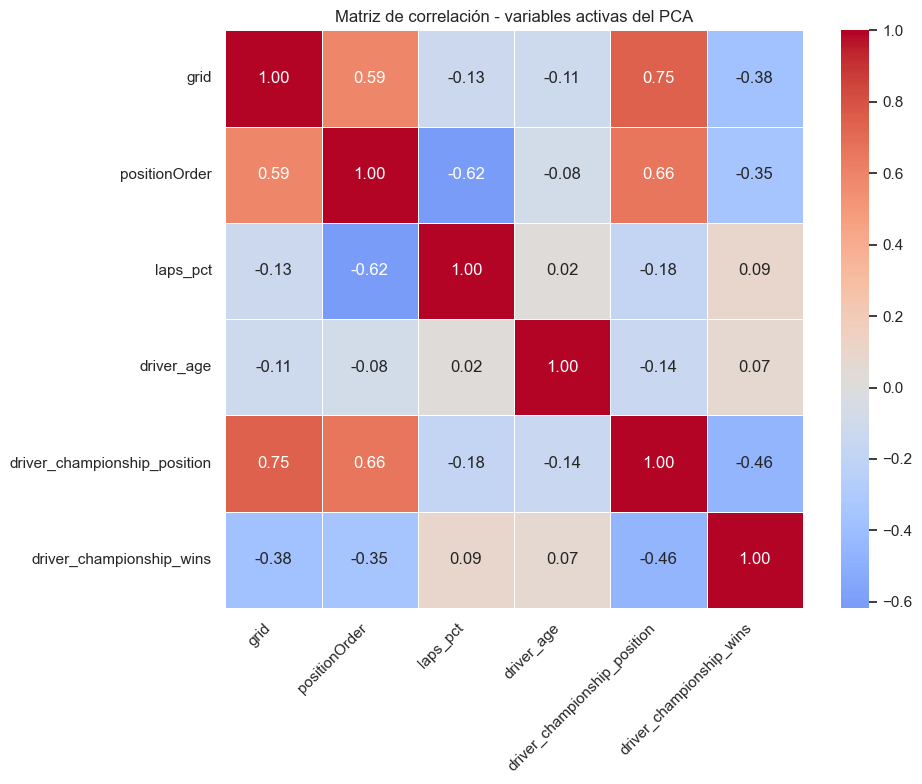

In [25]:
# ============================================================
# 7) MATRIZ DE CORRELACIÓN DE VARIABLES ACTIVAS
# ============================================================

corr_pca = Z_df.corr()

display(corr_pca.round(3))

corr_pca.to_csv(DATA_PROCESSED / "formula1_pca_matriz_correlacion_variables_activas.csv")

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_pca,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True
)
plt.title("Matriz de correlación - variables activas del PCA")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_matriz_correlacion_variables_activas.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Ajuste del PCA

Se ajusta el PCA con todas las componentes posibles. Si la matriz tiene $p$ variables activas, se obtienen hasta $p$ componentes principales.

Luego se analizan:

- **Autovalores:** cantidad de varianza explicada por cada componente.
- **Proporción de varianza explicada:** porcentaje de información retenida por cada componente.
- **Varianza acumulada:** porcentaje total retenido al conservar las primeras componentes.

In [26]:
# ============================================================
# 8) AJUSTE DEL PCA
# ============================================================

pca = PCA()
Z_pca = pca.fit_transform(Z)

componentes = [f"CP{i}" for i in range(1, Z_pca.shape[1] + 1)]

varianza_pca = pd.DataFrame({
    "componente": componentes,
    "autovalor": pca.explained_variance_,
    "varianza_explicada": pca.explained_variance_ratio_,
    "varianza_acumulada": np.cumsum(pca.explained_variance_ratio_)
})

# Criterios orientativos para evaluar componentes.
K_KAISER = int((pca.explained_variance_ > 1).sum())
K_KAISER = max(K_KAISER, 2)

UMBRAL_VARIANZA_CLUSTER = 0.80
K_UMBRAL = int(np.argmax(varianza_pca["varianza_acumulada"].values >= UMBRAL_VARIANZA_CLUSTER) + 1)
K_UMBRAL = max(K_UMBRAL, 2)

K_CLUSTER = 2

print("Cantidad de componentes según regla de Kaiser/autovalor > 1:", K_KAISER)
print(f"Cantidad de componentes para alcanzar al menos {UMBRAL_VARIANZA_CLUSTER:.0%} de varianza acumulada:", K_UMBRAL)
print("Cantidad de componentes elegidas para clustering:", K_CLUSTER)
print(
    "Varianza acumulada con las componentes elegidas:",
    f"{varianza_pca.loc[K_CLUSTER - 1, 'varianza_acumulada']:.2%}"
)

display(varianza_pca.round(4))

varianza_pca.to_csv(DATA_PROCESSED / "formula1_pca_varianza_explicada.csv", index=False)

Cantidad de componentes según regla de Kaiser/autovalor > 1: 2
Cantidad de componentes para alcanzar al menos 80% de varianza acumulada: 3
Cantidad de componentes elegidas para clustering: 2
Varianza acumulada con las componentes elegidas: 65.33%


,componente,autovalor,varianza_explicada,varianza_acumulada
0,CP1,2.7997,0.4666,0.4666
1,CP2,1.1205,0.1867,0.6533
2,CP3,0.9642,0.1607,0.8140
3,CP4,0.6801,0.1133,0.9273
4,CP5,0.2526,0.0421,0.9694
5,CP6,0.1835,0.0306,1.0000


**Decisión final**: Para seleccionar las componentes a utilizar en el clustering se evaluaron dos criterios. Por un lado, la regla de Kaiser indica conservar las componentes con autovalor mayor a 1. Según este criterio, se retienen las dos primeras componentes principales: CP1 y CP2.

Por otro lado, el criterio de varianza acumulada indicaría que para alcanzar aproximadamente el 80% de la variabilidad total sería necesario incluir también CP3. Sin embargo, al interpretar las cargas factoriales se observa que CP3 está explicada principalmente por `driver_age`, es decir, por la edad del piloto.

Como el objetivo del clustering es construir perfiles de desempeño en carrera, se decidió no incluir CP3 en la matriz final. De esta forma, la decisión queda respaldada tanto por la regla de Kaiser como por la interpretación sustantiva de las componentes.

## 9. Scree plot

El scree plot muestra los autovalores de cada componente. La línea horizontal en 1 representa la regla de Kaiser: conservar componentes con autovalor mayor a 1.

Esta regla tiene sentido en PCA con variables estandarizadas, porque cada variable original aporta varianza 1. Entonces una componente con autovalor mayor a 1 explica más varianza que una variable original promedio.

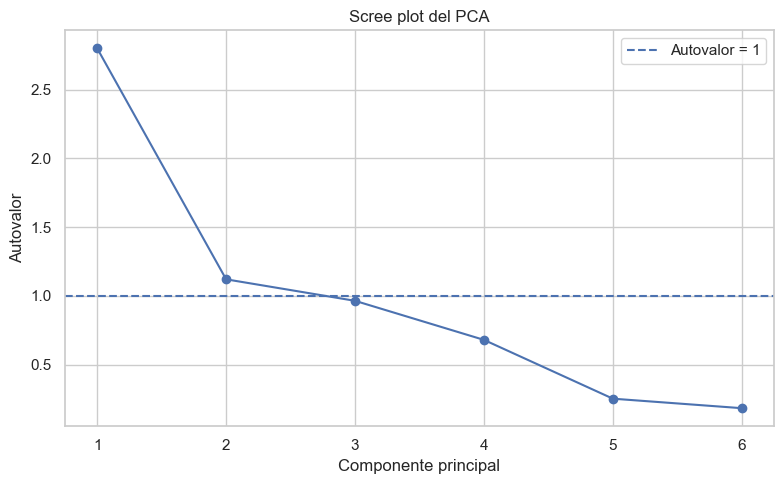

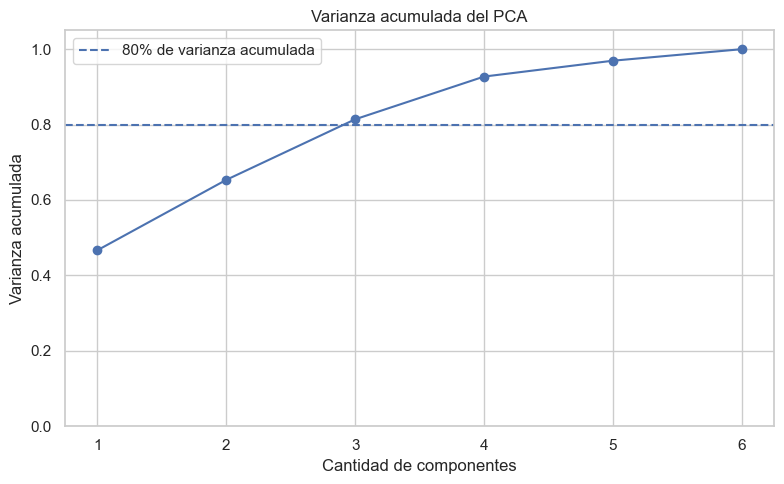

In [27]:
# ============================================================
# 9) SCREE PLOT
# ============================================================

indices = np.arange(1, len(pca.explained_variance_) + 1)

plt.figure(figsize=(8, 5))
plt.plot(indices, pca.explained_variance_, marker="o")
plt.axhline(y=1, linestyle="--", label="Autovalor = 1")
plt.xticks(indices)
plt.xlabel("Componente principal")
plt.ylabel("Autovalor")
plt.title("Scree plot del PCA")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_scree_plot.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(indices, varianza_pca["varianza_acumulada"], marker="o")
plt.axhline(y=UMBRAL_VARIANZA_CLUSTER, linestyle="--", label=f"{UMBRAL_VARIANZA_CLUSTER:.0%} de varianza acumulada")
plt.xticks(indices)
plt.ylim(0, 1.05)
plt.xlabel("Cantidad de componentes")
plt.ylabel("Varianza acumulada")
plt.title("Varianza acumulada del PCA")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_varianza_acumulada.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Contribuciones de las variables

Las contribuciones permiten ver qué variables pesan más en cada componente. En este notebook se calcula la contribución como el cuadrado del coeficiente de cada variable en la componente.

La línea horizontal representa una contribución promedio esperada de $1/p$, donde $p$ es la cantidad de variables activas. Las variables por encima de esa línea tienen una contribución superior al promedio para esa componente.

,CP1,CP2
grid,0.238,0.064
positionOrder,0.272,0.105
laps_pct,0.081,0.582
driver_age,0.012,0.105
driver_championship_position,0.270,0.051
driver_championship_wins,0.127,0.093


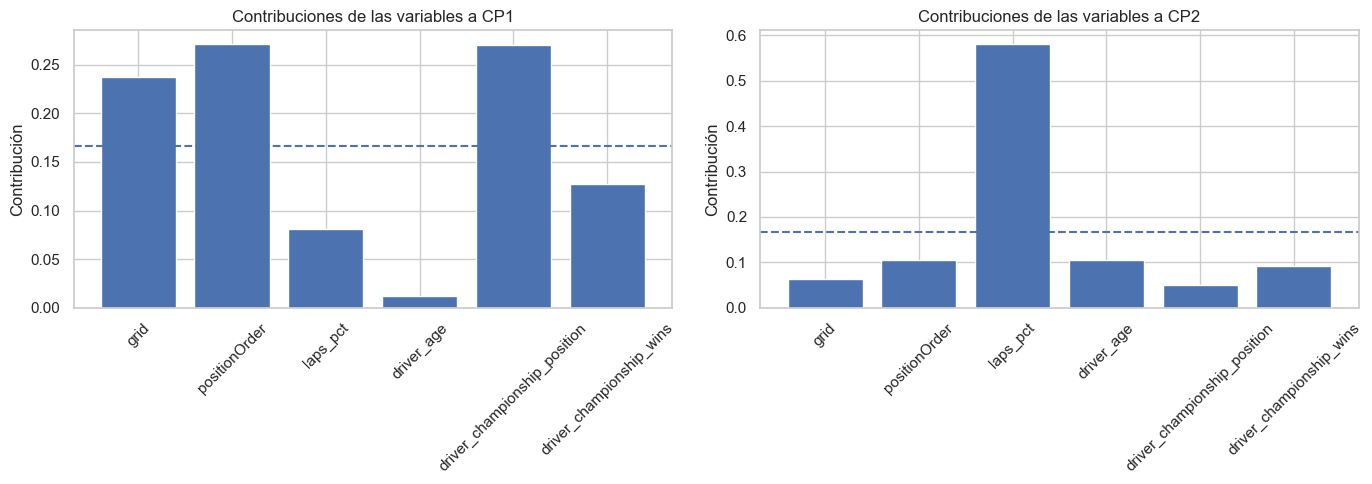

In [28]:
# ============================================================
# 10) CONTRIBUCIONES DE VARIABLES
# ============================================================

contribuciones = pd.DataFrame(
    pca.components_.T ** 2,
    index=variables_pca_activas,
    columns=componentes
)

contribuciones.to_csv(DATA_PROCESSED / "formula1_pca_contribuciones.csv")

display(contribuciones.iloc[:, :K_CLUSTER].round(3))

# Gráfico de contribuciones para las primeras componentes seleccionadas.
n_componentes_graf = min(K_CLUSTER, 4)
cols = 2
rows = int(np.ceil(n_componentes_graf / cols))

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
axes = np.array(axes).reshape(-1)

for i in range(n_componentes_graf):
    ax = axes[i]
    cp = f"CP{i+1}"
    ax.bar(contribuciones.index, contribuciones[cp])
    ax.axhline(y=1 / len(variables_pca_activas), linestyle="--")
    ax.set_title(f"Contribuciones de las variables a {cp}")
    ax.set_ylabel("Contribución")
    ax.tick_params(axis="x", rotation=45)

for j in range(n_componentes_graf, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_contribuciones_componentes_seleccionadas.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. Cargas factoriales o loadings

Las cargas ayudan a interpretar el sentido de las componentes. Muestran la relación entre cada variable original y cada componente principal.

Una carga alta y positiva indica que la variable se asocia positivamente con esa componente. Una carga alta y negativa indica asociación en sentido contrario.

In [29]:
# ============================================================
# 11) LOADINGS
# ============================================================

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

loadings_df = pd.DataFrame(
    loadings,
    index=variables_pca_activas,
    columns=componentes
)

loadings_df.to_csv(DATA_PROCESSED / "formula1_pca_loadings.csv")

display(loadings_df.iloc[:, :K_CLUSTER].round(3))

# Tabla auxiliar para interpretar las variables más importantes de cada componente.
def resumen_loadings(loadings_df, cp, top_n=4):
    serie = loadings_df[cp].sort_values()
    negativos = serie[serie < 0].head(top_n)
    positivos = serie[serie > 0].tail(top_n).sort_values(ascending=False)

    partes = []
    if len(negativos) > 0:
        partes.append(
            negativos.rename("loading")
            .reset_index()
            .rename(columns={"index": "variable"})
            .assign(sentido="negativo")
        )
    if len(positivos) > 0:
        partes.append(
            positivos.rename("loading")
            .reset_index()
            .rename(columns={"index": "variable"})
            .assign(sentido="positivo")
        )

    if len(partes) == 0:
        return pd.DataFrame(columns=["sentido", "variable", "loading"])

    resumen = pd.concat(partes, ignore_index=True)
    return resumen[["sentido", "variable", "loading"]]

for cp in componentes[:K_CLUSTER]:
    print("\n" + "=" * 80)
    print(f"Variables más asociadas a {cp}")
    print("=" * 80)
    display(resumen_loadings(loadings_df, cp, top_n=4).round(3))

,CP1,CP2
grid,0.816,0.269
positionOrder,0.872,-0.343
laps_pct,-0.477,0.807
driver_age,-0.184,-0.343
driver_championship_position,0.870,0.240
driver_championship_wins,-0.597,-0.323



Variables más asociadas a CP1


,sentido,variable,loading
0,negativo,driver_championship_wins,-0.597
1,negativo,laps_pct,-0.477
2,negativo,driver_age,-0.184
3,positivo,positionOrder,0.872
4,positivo,driver_championship_position,0.870
5,positivo,grid,0.816



Variables más asociadas a CP2


,sentido,variable,loading
0,negativo,driver_age,-0.343
1,negativo,positionOrder,-0.343
2,negativo,driver_championship_wins,-0.323
3,positivo,laps_pct,0.807
4,positivo,grid,0.269
5,positivo,driver_championship_position,0.240


## 12. Gráfico de cargas

El círculo de correlaciones permite visualizar conjuntamente las variables y su relación con las primeras componentes.

Reglas básicas de lectura:

- Variables cercanas entre sí tienden a estar positivamente relacionadas.
- Variables en direcciones opuestas tienden a estar negativamente relacionadas.
- Variables cerca del borde del círculo están mejor representadas en el plano mostrado.
- Variables cerca del centro están peor representadas por esas dos componentes.

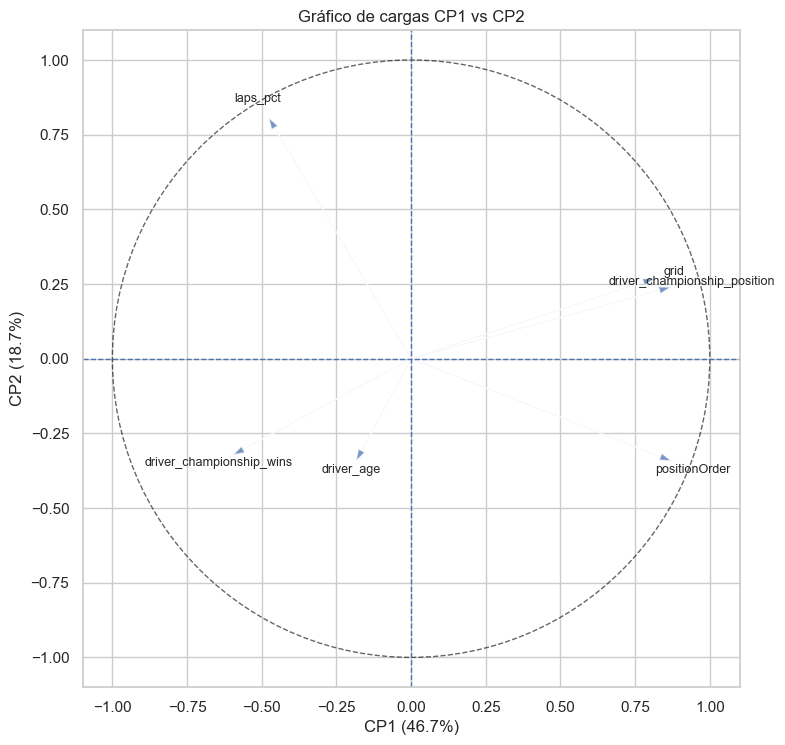

In [30]:
# ============================================================
# 12) GRÁFICO DE CARGAS
# ============================================================

def graficar_cargas(loadings_df, cp_x="CP1", cp_y="CP2", nombre_archivo=None):
    fig, ax = plt.subplots(figsize=(8, 8))
    
    circle = Circle((0, 0), 1, facecolor="none", edgecolor="black", linestyle="--", alpha=0.6)
    ax.add_patch(circle)
    
    ax.axhline(y=0, linestyle="--", linewidth=1)
    ax.axvline(x=0, linestyle="--", linewidth=1)
    
    for variable in loadings_df.index:
        x = loadings_df.loc[variable, cp_x]
        y = loadings_df.loc[variable, cp_y]
        ax.arrow(
            0, 0, x, y,
            alpha=0.75,
            head_width=0.025,
            head_length=0.04,
            length_includes_head=True
        )
        ax.text(x * 1.08, y * 1.08, variable, ha="center", va="center", fontsize=9)
    
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(f"{cp_x} ({varianza_pca.loc[int(cp_x[2:]) - 1, 'varianza_explicada'] * 100:.1f}%)")
    ax.set_ylabel(f"{cp_y} ({varianza_pca.loc[int(cp_y[2:]) - 1, 'varianza_explicada'] * 100:.1f}%)")
    ax.set_title(f"Gráfico de cargas {cp_x} vs {cp_y}")
    ax.grid(True)
    plt.tight_layout()
    
    if nombre_archivo is not None:
        plt.savefig(FIGURES_DIR / nombre_archivo, dpi=300, bbox_inches="tight")
    
    plt.show()

# Primer plano principal
graficar_cargas(loadings_df, "CP1", "CP2", "pca_cargas_cp1_cp2.png")

# Planos adicionales útiles para interpretar las primeras componentes retenidas.
if K_CLUSTER >= 3:
    graficar_cargas(loadings_df, "CP1", "CP3", "pca_cargas_cp1_cp3.png")

if K_CLUSTER >= 4:
    graficar_cargas(loadings_df, "CP1", "CP4", "pca_cargas_cp1_cp4.png")

### Interpretación de las componentes

- **CP1:** representa principalmente el desempeño posicional general. En el sentido positivo aparecen `grid`, `positionOrder` y `driver_championship_position`, variables donde valores más altos indican peores posiciones. En sentido opuesto aparece `driver_championship_wins`, por lo que los valores negativos de CP1 se asocian con mejores desempeños competitivos.

- **CP2:** representa principalmente la continuidad en carrera. Está fuertemente asociada a `laps_pct`, por lo que valores altos de CP2 indican una mayor proporción de carrera completada. En cambio, valores bajos se relacionan con carreras incompletas o abandonos.



## 13. Scores de los individuos

Los scores son las coordenadas de cada observación en el nuevo sistema de componentes principales.

En este caso, cada fila representa un resultado individual de un piloto en una carrera. Graficar los scores permite ver si existen patrones según variables suplementarias como:

- resultado final;
- grupo de largada;
- estado final de carrera;
- década;
- constructor.

In [31]:
# ============================================================
# 13) SCORES DE LOS INDIVIDUOS
# ============================================================

scores_df = pd.DataFrame(
    Z_pca,
    columns=componentes,
    index=X.index
)

# Se unen scores con variables suplementarias para interpretación.
scores_metadata = pd.concat(
    [df_pca_limpio[["indice_original"] + [c for c in variables_suplementarias if c in df_pca_limpio.columns]].reset_index(drop=True),
     scores_df.reset_index(drop=True)],
    axis=1
)

scores_metadata.to_csv(DATA_PROCESSED / "formula1_pca_scores_todas_componentes.csv", index=False)

print("Scores con todas las componentes guardados en:")
print(DATA_PROCESSED / "formula1_pca_scores_todas_componentes.csv")

print("Dimensiones:")
print(scores_metadata.shape)

display(scores_metadata.head())

Scores con todas las componentes guardados en:
/Users/juani/Desktop/Facultad/3er año/Analisis Multivariado y Descrubrimiento de Patrones/Analisis-multivariado/data/processed/formula1_pca_scores_todas_componentes.csv
Dimensiones:
(9760, 30)


,indice_original,resultId,raceId,driverId,constructorId,circuitId,year,decada,race_name,race_date,circuit_name,circuit_country,driver_name,driver_nationality,constructor_name,constructor_nationality,largada_grupo,resultado_grupo,status,status_grupo,podio,top10,victoria,posiciones_ganadas,CP1,CP2,CP3,CP4,CP5,CP6
0,0,26508,1132,857,1,9,2024,2020s,British Grand Prix,2024-07-07,Silverstone Circuit,UK,Oscar Piastri,Australian,McLaren,British,Top 5,Top 10,Finished,Clasificado / terminó,0,1,0,1,-1.472088,0.684338,-0.918121,-0.985693,0.135969,-0.102979
1,1,34,19,21,10,2,2008,2000s,Malaysian Grand Prix,2008-03-23,Sepang International Circuit,Malaysia,Giancarlo Fisichella,Italian,Force India,Indian,Fondo,Fuera del top 10,+1 Lap,Clasificado / terminó,0,0,0,5,0.734821,0.294959,1.628005,0.488619,0.203580,-0.035662
2,2,1370,82,39,17,10,2005,2000s,German Grand Prix,2005-07-24,Hockenheimring,Germany,Narain Karthikeyan,Indian,Jordan,Irish,Fondo,Fuera del top 10,+3 Laps,Clasificado / terminó,0,0,0,3,1.570792,0.595658,0.403169,0.619870,0.135665,0.276678
3,3,7871,16,16,10,18,2009,2000s,Brazilian Grand Prix,2009-10-18,Autódromo José Carlos Pace,Brazil,Adrian Sutil,German,Force India,Indian,Top 5,Fuera del top 10,Accident,Incidente / abandono,0,0,0,-15,1.398533,-2.707115,-1.034964,-1.181776,-0.980578,-0.871881
4,4,3273,173,21,22,22,2000,2000s,Japanese Grand Prix,2000-10-08,Suzuka Circuit,Japan,Giancarlo Fisichella,Italian,Benetton,Italian,Fondo,Fuera del top 10,+1 Lap,Clasificado / terminó,0,0,0,-2,-0.063448,0.141822,-0.010596,-0.291537,0.451447,0.948726


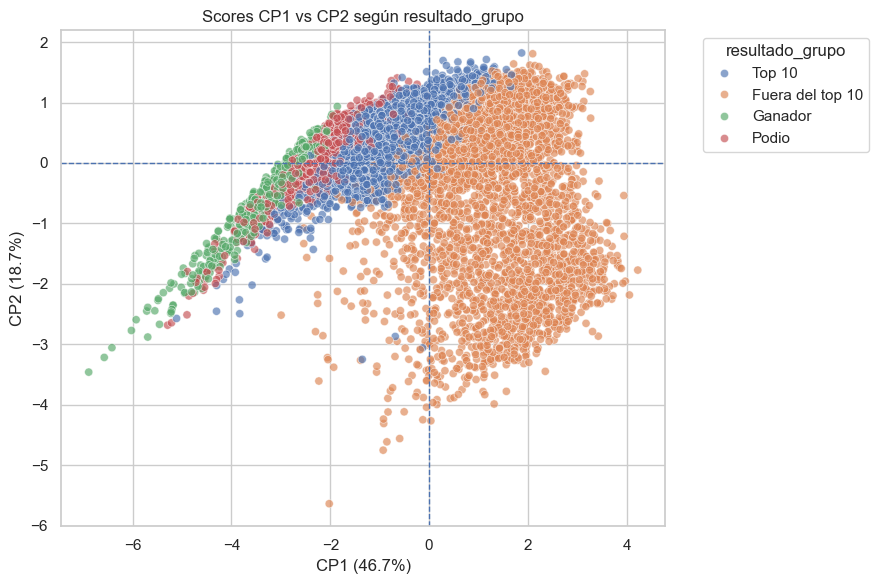

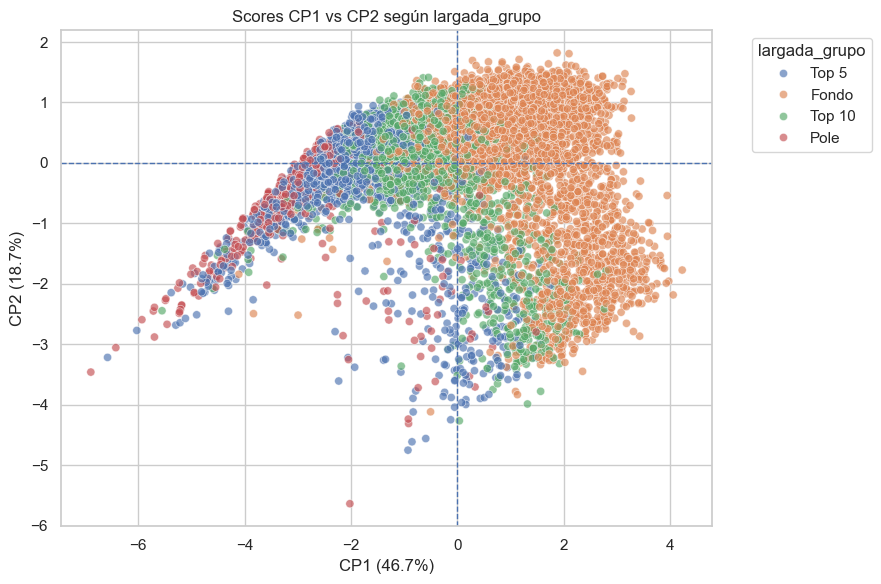

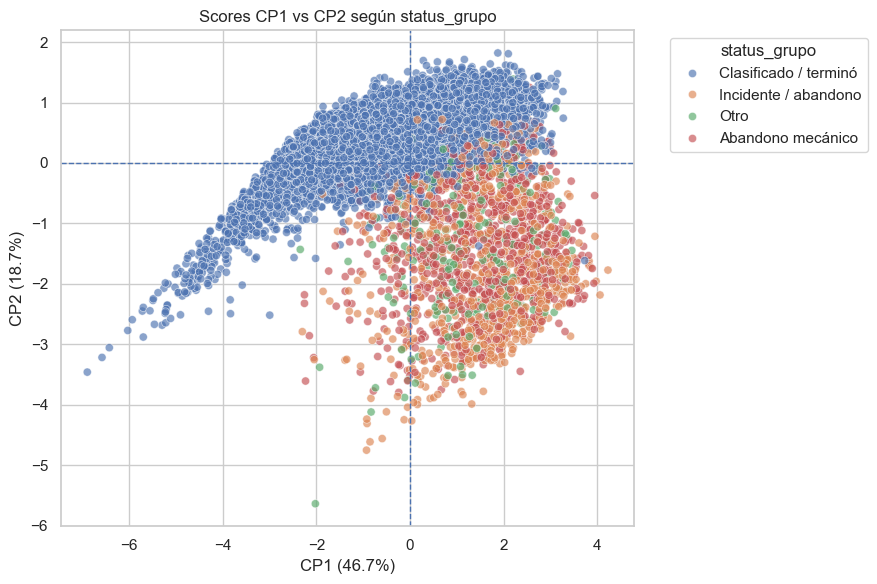

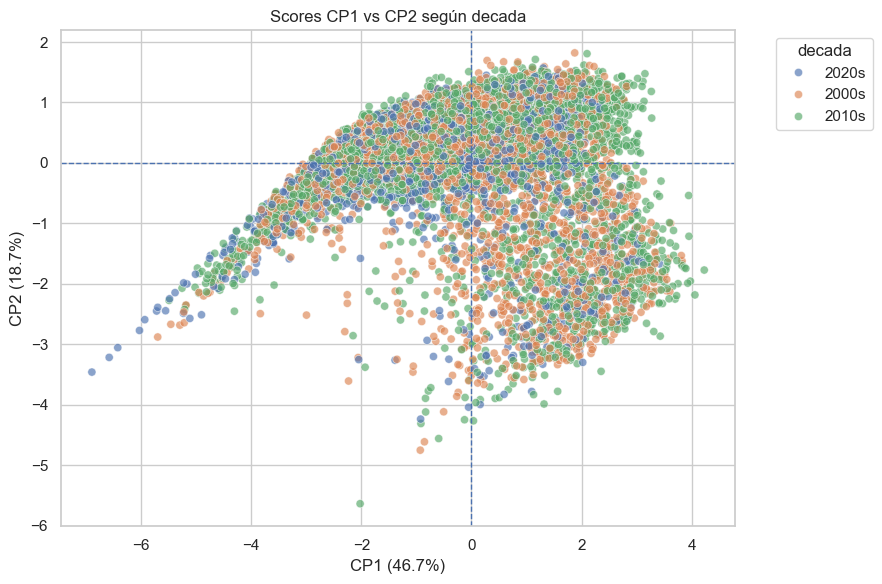

In [32]:
# ============================================================
# 13.1) GRÁFICOS DE SCORES SEGÚN VARIABLES SUPLEMENTARIAS
# ============================================================

def graficar_scores_categoria(df_scores, categoria, cp_x="CP1", cp_y="CP2", top_n=None, nombre_archivo=None):
    if categoria not in df_scores.columns:
        print(f"La variable {categoria} no está disponible.")
        return
    
    datos = df_scores[[cp_x, cp_y, categoria]].dropna().copy()
    
    if top_n is not None:
        principales = datos[categoria].value_counts().head(top_n).index
        datos[categoria] = np.where(datos[categoria].isin(principales), datos[categoria], "Otros")
    
    plt.figure(figsize=(9, 6))
    sns.scatterplot(
        data=datos,
        x=cp_x,
        y=cp_y,
        hue=categoria,
        alpha=0.65,
        s=35
    )
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.axvline(0, linestyle="--", linewidth=1)
    plt.xlabel(f"{cp_x} ({varianza_pca.loc[int(cp_x[2:]) - 1, 'varianza_explicada'] * 100:.1f}%)")
    plt.ylabel(f"{cp_y} ({varianza_pca.loc[int(cp_y[2:]) - 1, 'varianza_explicada'] * 100:.1f}%)")
    plt.title(f"Scores {cp_x} vs {cp_y} según {categoria}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title=categoria)
    plt.tight_layout()
    
    if nombre_archivo is not None:
        plt.savefig(FIGURES_DIR / nombre_archivo, dpi=300, bbox_inches="tight")
    
    plt.show()

# Gráficos principales de interpretación.
graficar_scores_categoria(
    scores_metadata,
    categoria="resultado_grupo",
    cp_x="CP1",
    cp_y="CP2",
    nombre_archivo="pca_scores_cp1_cp2_resultado_grupo.png"
)

graficar_scores_categoria(
    scores_metadata,
    categoria="largada_grupo",
    cp_x="CP1",
    cp_y="CP2",
    nombre_archivo="pca_scores_cp1_cp2_largada_grupo.png"
)

graficar_scores_categoria(
    scores_metadata,
    categoria="status_grupo",
    cp_x="CP1",
    cp_y="CP2",
    nombre_archivo="pca_scores_cp1_cp2_status_grupo.png"
)

graficar_scores_categoria(
    scores_metadata,
    categoria="decada",
    cp_x="CP1",
    cp_y="CP2",
    nombre_archivo="pca_scores_cp1_cp2_decada.png"
)

## 14. Observaciones extremas en el plano principal

Las observaciones alejadas del origen son casos con combinaciones de variables menos habituales. No necesariamente son errores: pueden representar carreras, pilotos o contextos particulares que se diferencian fuertemente del promedio.

,indice_original,year,race_name,driver_name,constructor_name,grid,positionOrder,resultado_grupo,largada_grupo,status_grupo,CP1,CP2,distancia_cp1_cp2
3263,3344,2023,Abu Dhabi Grand Prix,Max Verstappen,Red Bull,1,1,Ganador,Pole,Clasificado / terminó,-6.890,-3.461,7.711
8843,9061,2023,Las Vegas Grand Prix,Max Verstappen,Red Bull,2,1,Ganador,Top 5,Clasificado / terminó,-6.576,-3.218,7.321
9408,9642,2023,São Paulo Grand Prix,Max Verstappen,Red Bull,1,1,Ganador,Pole,Clasificado / terminó,-6.420,-3.056,7.110
6442,6603,2023,Mexico City Grand Prix,Max Verstappen,Red Bull,3,1,Ganador,Top 5,Clasificado / terminó,-6.026,-2.772,6.633
423,437,2022,Abu Dhabi Grand Prix,Max Verstappen,Red Bull,1,1,Ganador,Pole,Clasificado / terminó,-5.930,-2.593,6.472
2798,2865,2004,Japanese Grand Prix,Michael Schumacher,Ferrari,1,1,Ganador,Pole,Clasificado / terminó,-5.695,-2.880,6.382
663,681,2023,Qatar Grand Prix,Max Verstappen,Red Bull,1,1,Ganador,Pole,Clasificado / terminó,-5.715,-2.450,6.218
1909,1957,2022,Mexico City Grand Prix,Max Verstappen,Red Bull,1,1,Ganador,Pole,Clasificado / terminó,-5.694,-2.389,6.175
3740,3834,2004,Hungarian Grand Prix,Michael Schumacher,Ferrari,1,1,Ganador,Pole,Clasificado / terminó,-5.457,-2.670,6.075
8877,9095,2023,United States Grand Prix,Max Verstappen,Red Bull,6,1,Ganador,Top 10,Clasificado / terminó,-5.552,-2.446,6.067


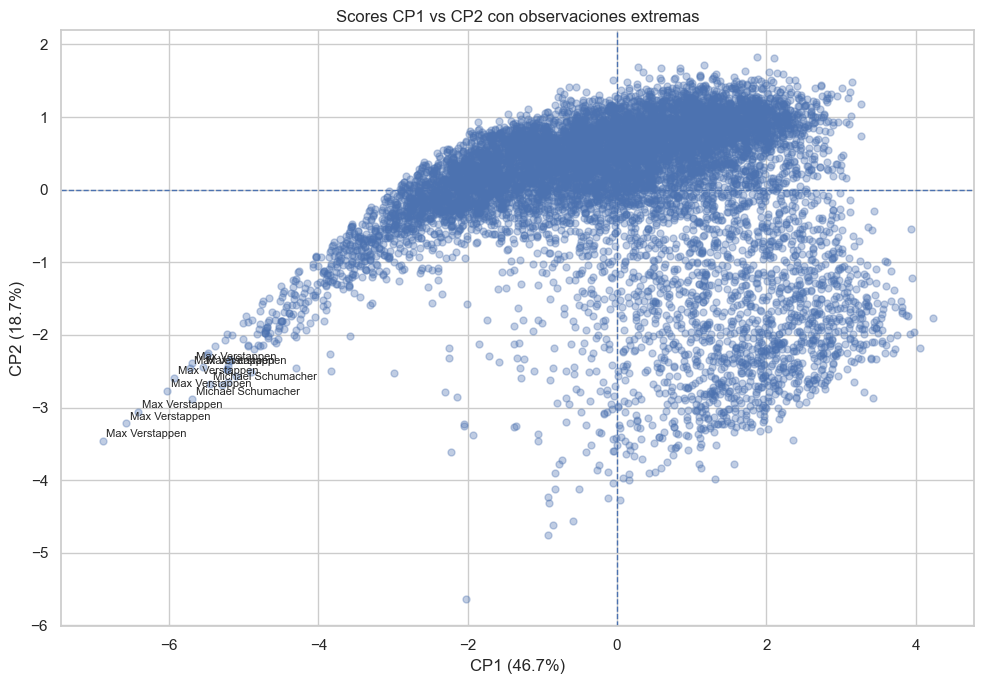

In [33]:
# ============================================================
# 14) OBSERVACIONES EXTREMAS EN CP1-CP2
# ============================================================

scores_metadata["distancia_cp1_cp2"] = np.sqrt(scores_metadata["CP1"]**2 + scores_metadata["CP2"]**2)

# Algunas variables activas no estaban en variables suplementarias; las agregamos para esta tabla si hace falta.
for col in ["grid", "positionOrder", "race_points"]:
    if col not in scores_metadata.columns and col in X.columns:
        scores_metadata[col] = X.reset_index(drop=True)[col]

columnas_atipicos = [
    col for col in [
        "indice_original",
        "year",
        "race_name",
        "driver_name",
        "constructor_name",
        "grid",
        "positionOrder",
        "race_points",
        "resultado_grupo",
        "largada_grupo",
        "status_grupo",
        "CP1",
        "CP2",
        "distancia_cp1_cp2"
    ]
    if col in scores_metadata.columns
]

atipicos_cp1_cp2 = scores_metadata.nlargest(10, "distancia_cp1_cp2")[columnas_atipicos]

display(atipicos_cp1_cp2.round(3))

atipicos_cp1_cp2.to_csv(DATA_PROCESSED / "formula1_pca_observaciones_extremas_cp1_cp2.csv", index=False)

plt.figure(figsize=(10, 7))
plt.scatter(scores_metadata["CP1"], scores_metadata["CP2"], alpha=0.35, s=25)
plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)

for _, fila in atipicos_cp1_cp2.iterrows():
    etiqueta = str(fila["driver_name"]) if "driver_name" in fila.index else str(fila["indice_original"])
    plt.text(fila["CP1"] + 0.05, fila["CP2"] + 0.05, etiqueta, fontsize=8)

plt.xlabel(f"CP1 ({varianza_pca.loc[0, 'varianza_explicada'] * 100:.1f}%)")
plt.ylabel(f"CP2 ({varianza_pca.loc[1, 'varianza_explicada'] * 100:.1f}%)")
plt.title("Scores CP1 vs CP2 con observaciones extremas")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_scores_cp1_cp2_atipicos.png", dpi=300, bbox_inches="tight")
plt.show()

## 15. Guardado de la matriz del PCA para clustering

Para el análisis cluster no se utilizarán directamente todas las variables originales, ya que algunas presentan correlaciones entre sí y podrían quedar sobrerrepresentadas. En su lugar, se guarda una matriz reducida con los scores del PCA.

La matriz principal para clustering se guarda utilizando únicamente **CP1 y CP2**, de acuerdo con la decisión metodológica tomada en la sección anterior. También se conserva un archivo con todas las componentes para posibles revisiones posteriores.

In [34]:
# ============================================================
# 15) GUARDADO DE MATRIZ PCA PARA CLUSTERING
# ============================================================

componentes_cluster = [f"CP{i}" for i in range(1, K_CLUSTER + 1)]

columnas_metadata_cluster = [
    col for col in [
        "indice_original",
        "resultId",
        "raceId",
        "driverId",
        "constructorId",
        "circuitId",
        "year",
        "decada",
        "race_name",
        "driver_name",
        "constructor_name",
        "circuit_name",
        "circuit_country",
        "largada_grupo",
        "resultado_grupo",
        "status_grupo",
        "podio",
        "top10",
        "victoria",
        "posiciones_ganadas"
    ]
    if col in scores_metadata.columns
]

matriz_pca_cluster = scores_metadata[columnas_metadata_cluster + componentes_cluster].copy()

archivo_scores_cluster = DATA_PROCESSED / "formula1_pca_scores_cluster.csv"
matriz_pca_cluster.to_csv(archivo_scores_cluster, index=False)

# Archivo adicional solo con las componentes, útil si el algoritmo de clustering debe recibir únicamente variables numéricas.
archivo_matriz_numerica_cluster = DATA_PROCESSED / "formula1_pca_matriz_cluster_numerica.csv"
matriz_pca_cluster[componentes_cluster].to_csv(archivo_matriz_numerica_cluster, index=False)

print("Componentes usadas para clustering:")
print(componentes_cluster)

print("\nMatriz PCA con metadata guardada en:")
print(archivo_scores_cluster)
print("Dimensiones:", matriz_pca_cluster.shape)

print("\nMatriz PCA solo numérica guardada en:")
print(archivo_matriz_numerica_cluster)
print("Dimensiones:", matriz_pca_cluster[componentes_cluster].shape)

display(matriz_pca_cluster.head())

Componentes usadas para clustering:
['CP1', 'CP2']

Matriz PCA con metadata guardada en:
/Users/juani/Desktop/Facultad/3er año/Analisis Multivariado y Descrubrimiento de Patrones/Analisis-multivariado/data/processed/formula1_pca_scores_cluster.csv
Dimensiones: (9760, 22)

Matriz PCA solo numérica guardada en:
/Users/juani/Desktop/Facultad/3er año/Analisis Multivariado y Descrubrimiento de Patrones/Analisis-multivariado/data/processed/formula1_pca_matriz_cluster_numerica.csv
Dimensiones: (9760, 2)


,indice_original,resultId,raceId,driverId,constructorId,circuitId,year,decada,race_name,driver_name,constructor_name,circuit_name,circuit_country,largada_grupo,resultado_grupo,status_grupo,podio,top10,victoria,posiciones_ganadas,CP1,CP2
0,0,26508,1132,857,1,9,2024,2020s,British Grand Prix,Oscar Piastri,McLaren,Silverstone Circuit,UK,Top 5,Top 10,Clasificado / terminó,0,1,0,1,-1.472088,0.684338
1,1,34,19,21,10,2,2008,2000s,Malaysian Grand Prix,Giancarlo Fisichella,Force India,Sepang International Circuit,Malaysia,Fondo,Fuera del top 10,Clasificado / terminó,0,0,0,5,0.734821,0.294959
2,2,1370,82,39,17,10,2005,2000s,German Grand Prix,Narain Karthikeyan,Jordan,Hockenheimring,Germany,Fondo,Fuera del top 10,Clasificado / terminó,0,0,0,3,1.570792,0.595658
3,3,7871,16,16,10,18,2009,2000s,Brazilian Grand Prix,Adrian Sutil,Force India,Autódromo José Carlos Pace,Brazil,Top 5,Fuera del top 10,Incidente / abandono,0,0,0,-15,1.398533,-2.707115
4,4,3273,173,21,22,22,2000,2000s,Japanese Grand Prix,Giancarlo Fisichella,Benetton,Suzuka Circuit,Japan,Fondo,Fuera del top 10,Clasificado / terminó,0,0,0,-2,-0.063448,0.141822


## 16. Conclusión del PCA

El Análisis de Componentes Principales permitió resumir la información de las variables numéricas activas en un conjunto reducido de dimensiones. Para seleccionar las componentes a utilizar en el clustering se evaluaron dos criterios: la regla de Kaiser y la varianza acumulada.

Según la regla de Kaiser, deben conservarse las componentes con autovalor mayor a 1. En este caso, dicho criterio sugiere retener las dos primeras componentes principales, **CP1** y **CP2**, que explican aproximadamente el 65% de la variabilidad total.

La **CP1** se interpreta como un eje de desempeño posicional general. En el sentido positivo se asocia con valores más altos de `grid`, `positionOrder` y `driver_championship_position`, es decir, peores posiciones de largada, llegada y campeonato. En sentido opuesto aparece `driver_championship_wins`, por lo que los valores negativos de CP1 se relacionan con mejores desempeños competitivos.

La **CP2** se interpreta como una dimensión vinculada a la continuidad en carrera, ya que está fuertemente asociada a `laps_pct`. Esta componente permite distinguir observaciones donde el piloto completó una mayor proporción de la carrera frente a casos de abandono o carrera incompleta.

Si se considerara el criterio de varianza acumulada, sería necesario incluir una tercera componente para alcanzar aproximadamente el 80% de la variabilidad total. Sin embargo, la **CP3** quedó asociada principalmente a la edad del piloto (`driver_age`) y no aportó una dimensión central para segmentar perfiles de desempeño en carrera.

Por lo tanto, para la etapa de clustering se utilizará la matriz formada por **CP1 y CP2**. Esta decisión queda respaldada por la regla de Kaiser y por la interpretación sustantiva de las componentes, priorizando la construcción de grupos claros e interpretables.



In [35]:
# ============================================================
# 16) RESUMEN AUTOMÁTICO PARA APOYAR LA INTERPRETACIÓN
# ============================================================

for cp in componentes[:K_CLUSTER]:
    print("\n" + "=" * 100)
    print(f"{cp}")
    print("=" * 100)
    
    var_exp = varianza_pca.loc[int(cp[2:]) - 1, "varianza_explicada"] * 100
    var_acum = varianza_pca.loc[int(cp[2:]) - 1, "varianza_acumulada"] * 100
    
    print(f"Varianza explicada por {cp}: {var_exp:.2f}%")
    print(f"Varianza acumulada hasta {cp}: {var_acum:.2f}%")
    
    serie_cp = loadings_df[cp]
    positivos = serie_cp[serie_cp > 0].sort_values(ascending=False).head(5)
    negativos = serie_cp[serie_cp < 0].sort_values(ascending=True).head(5)
    
    print("\nVariables con mayor peso positivo:")
    display(positivos.round(3))
    
    print("Variables con mayor peso negativo:")
    display(negativos.round(3))



CP1
Varianza explicada por CP1: 46.66%
Varianza acumulada hasta CP1: 46.66%

Variables con mayor peso positivo:


positionOrder                   0.872
driver_championship_position    0.870
grid                            0.816
Name: CP1, dtype: float64

Variables con mayor peso negativo:


driver_championship_wins   -0.597
laps_pct                   -0.477
driver_age                 -0.184
Name: CP1, dtype: float64


CP2
Varianza explicada por CP2: 18.67%
Varianza acumulada hasta CP2: 65.33%

Variables con mayor peso positivo:


laps_pct                        0.807
grid                            0.269
driver_championship_position    0.240
Name: CP2, dtype: float64

Variables con mayor peso negativo:


driver_age                 -0.343
positionOrder              -0.343
driver_championship_wins   -0.323
Name: CP2, dtype: float64

## 17. Archivos generados

Al ejecutar este notebook quedan guardados los siguientes archivos principales:

- `data/processed/formula1_pca_variables_activas.csv`
- `data/processed/formula1_pca_descripcion_variables_activas.csv`
- `data/processed/formula1_pca_matriz_estandarizada.csv`
- `data/processed/formula1_pca_matriz_correlacion_variables_activas.csv`
- `data/processed/formula1_pca_varianza_explicada.csv`
- `data/processed/formula1_pca_contribuciones.csv`
- `data/processed/formula1_pca_loadings.csv`
- `data/processed/formula1_pca_scores_todas_componentes.csv`
- `data/processed/formula1_pca_scores_cluster.csv`
- `data/processed/formula1_pca_matriz_cluster_numerica.csv`

Para el próximo paso de clustering, el archivo más importante es:

`data/processed/formula1_pca_scores_cluster.csv`

Si el algoritmo necesita solamente variables numéricas, se puede usar directamente:

`data/processed/formula1_pca_matriz_cluster_numerica.csv`